In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from lmfit.models import GaussianModel
import matplotlib as m

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [4]:
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
vac = "/2025-08-13/2025-08-13T102620_84577147-i0_JPA_vac_squeeze"
dd = datadict_from_hdf5(header + vac +"/data")

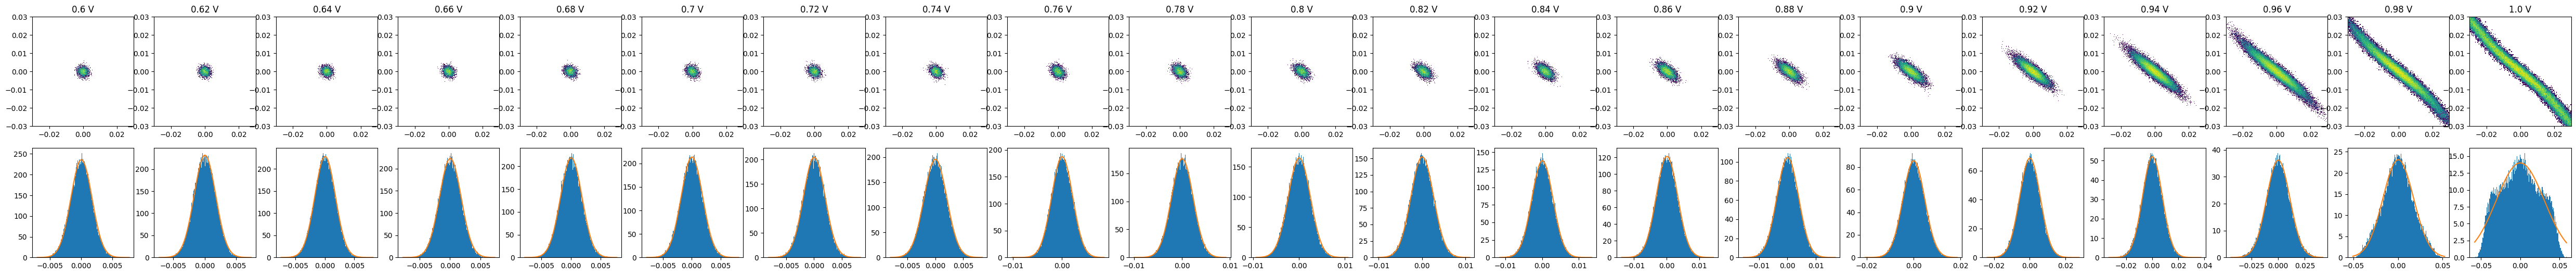

In [5]:
pump_amplitude = dd["pump_amplitude"]["values"]
s11 = dd["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    i = i
    s_11 = s11[i]
    s11_pca = PCA_transform(s_11.real, s_11.imag)[0]
    
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    # print(s_11.real)
    ax.hist2d(s_11.real, s_11.imag, bins=200, cmin=1, norm=m.colors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.set_xlim(-0.03, 0.03)
    ax.set_ylim(-0.03, 0.03)

    hist, bins = np.histogram(s11_pca, bins=200, density=True)
    model = GaussianModel()
    params = model.guess(hist, x = bins[1:])
    result = model.fit(hist, params, x = bins[1:])
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax2.hist(s11_pca, bins=200, density=True)
    # ax2.set_ylim(0, 70)
    ax2.plot(bins[1:], result.best_fit, label="gaussian fit")
# plt.legend()
plt.show()

phase optimization

(np.float64(0.03528296202978743), np.float64(0.44000000000000006))

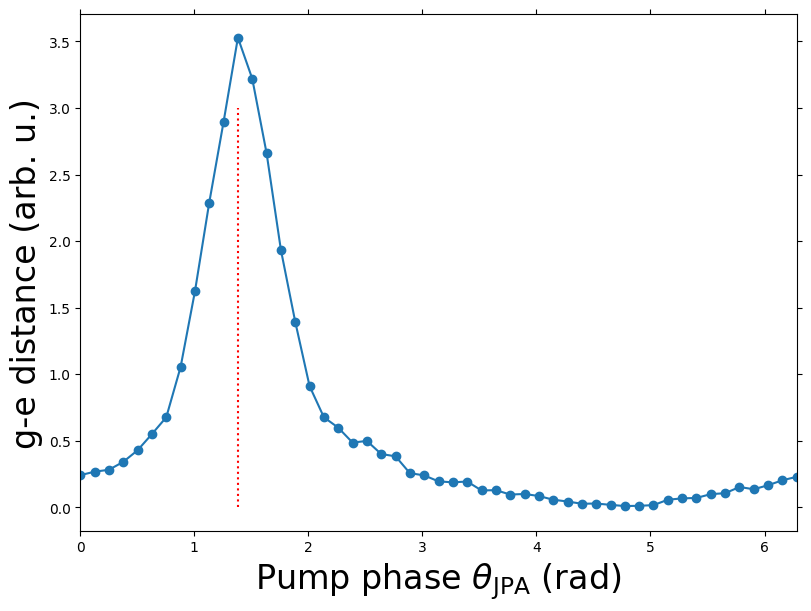

In [6]:
data = "/2025-08-13/2025-08-13T104958_d19f514a-i1_JPA_phase_optimization_for_ge"  #10dB
dd = datadict_from_hdf5(header + data +"/data")

fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

x = dd["phase"]["values"]
y = dd["distance"]["values"]
xy = x[4], np.abs(y)[4]
y_pca = PCA_transform(y.real, y.imag)[0]
plt.title("")
# plt.legend(title_fontsize=18, fontsize=18)
plt.ylabel("g-e distance (arb. u.)", size="large")
plt.xlabel(r"Pump phase $\theta_{\mathrm{JPA}}$ (rad)", size="large")
plt.xlim(0, 2*np.pi)
# plt.ylim(0, 10)
plt.plot(x*np.pi, np.abs(y)*1e2, 'o-')
plt.vlines(0.44*np.pi, 0, 3, color='r', linestyles='dotted')

np.max(np.abs(y)), np.abs(x[11])
# plt.savefig('ge_distance.png', bbox_inches='tight')

readout fidelity

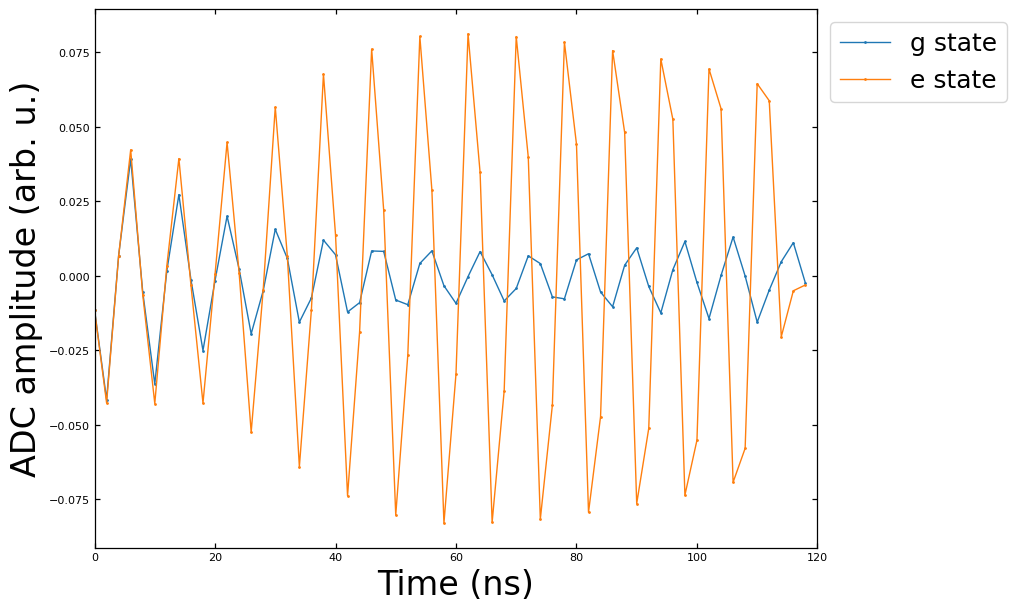

In [62]:
data ="/2025-08-13/2025-08-13T105133_0a05bf55-i2_readout_fidelity_threshold"
# data ="/2025-08-13/2025-08-13T104348_f4b6973d-i2_readout_fidelity_threshold"
# data ="/2025-08-13/2025-08-13T103434_aaa4d5f3-i2_readout_fidelity_threshold"

dd =datadict_from_hdf5(header + data +"/data")
time = dd["time"]["values"][0]
pulse_g = dd["pulse_g"]["values"][0]
pulse_e = dd["pulse_e"]["values"][0]

fig, ax = plt.subplots(figsize=(10,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.title("")
plt.plot(time, pulse_g, '.-', label = "g state")
plt.xlim(0, 120)
plt.plot(time, pulse_e,'.-', label = "e state")
plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.28, 1))
plt.xlabel("Time (ns)", size="large")
plt.ylabel("ADC amplitude (arb. u.)", size="large")
# plt.savefig('JPA_phase_opt.png', bbox_inches='tight')

plt.show()

[ 0.00108857  0.00068684  0.00211636 ...  0.00646637 -0.00441433
  0.00361009]


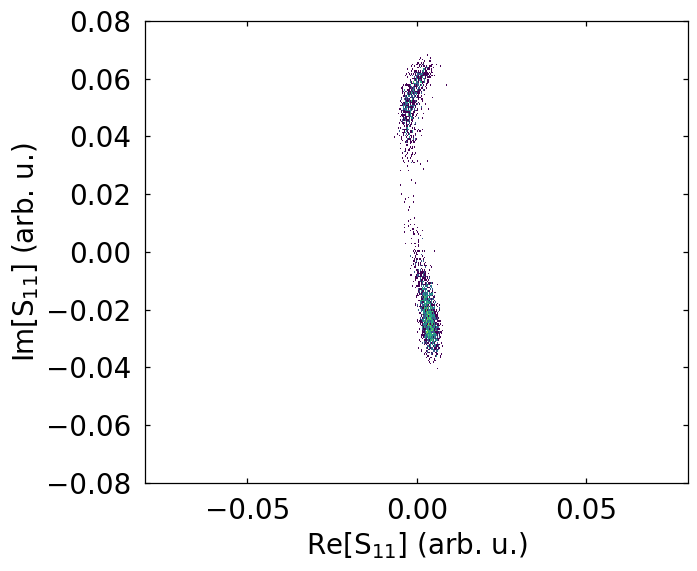

In [63]:
# data ="/2024-06-27/2024-06-27T185724_a73411de-82_readout_fidelity_threshold" #0.7
dd =datadict_from_hdf5(header + data +"/data")
time = dd["time"]["values"][0]
S11_g = dd["signal_g"]["values"][0]
S11_e = dd["signal_e"]["values"][0]
print(S11_g.real)

# s11_g_pca = PCA_transform(S11_g.real, S11_g.imag)[0]
# s11_e_pca = PCA_transform(S11_e.real, S11_e.imag)[0]

fig, ax = plt.subplots(1, 1, figsize=(7,6))
plt.rcParams["font.size"] = 20
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
plt.subplots_adjust(wspace=0.3)
ax.hist2d(S11_g.real, S11_g.imag, bins=200, cmin=1, norm=m.colors.LogNorm())
# ax[0].set_title("g")
ax.set_xlim(-0.08, 0.08)
ax.set_ylim(-0.08, 0.08)
ax.set_xlabel('Re[S$_{11}$] (arb. u.)')
ax.set_ylabel('Im[S$_{11}$] (arb. u.)')

# plt.savefig('signal_e.png', bbox_inches='tight')
plt.show()


thermal population

In [69]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

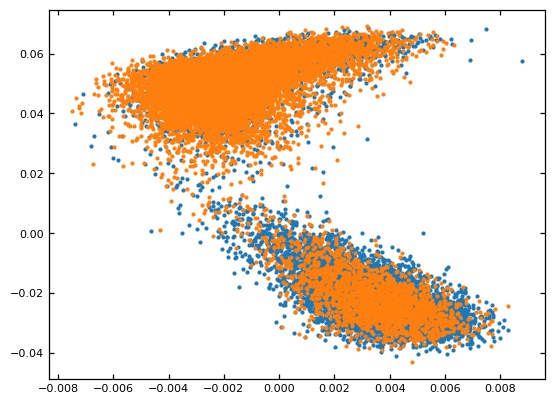

In [70]:
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()
plt.plot(signal_g.real, signal_g.imag, "o")
plt.plot(signal_e.real, signal_e.imag, "o")

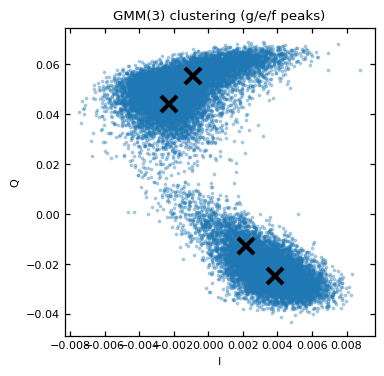

In [72]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

def to_IQ(arr):
    return np.vstack([arr.real, arr.imag]).T

X = np.vstack([to_IQ(signal_g), to_IQ(signal_e)])  # 全部まとめる

# 3つのクラスタ（g, e, f を期待）
gmm = GaussianMixture(n_components=4, covariance_type='full').fit(X)

labels = gmm.predict(X)   # 各点がどのクラスタに属するか
centers = gmm.means_      # shape (3, 2)
weights = gmm.weights_

plt.figure(figsize=(4,4))
plt.scatter(X[:,0], X[:,1], s=3, alpha=0.3)

for c in centers:
    plt.plot(c[0], c[1], "x", color="k", markersize=12, markeredgewidth=3)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("GMM(3) clustering (g/e/f peaks)")
plt.show()


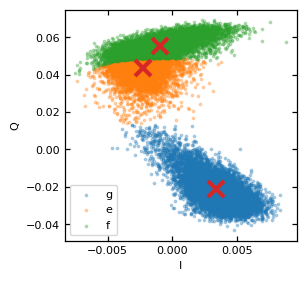

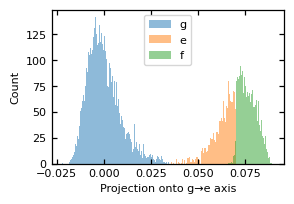

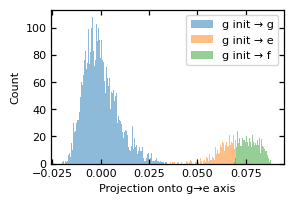

Initial state |g> → cluster fractions (g/e/f): [0.6577 0.1078 0.2345]


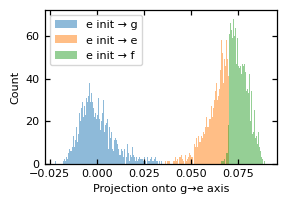

Initial state |e> → cluster fractions (g/e/f): [0.2024 0.3256 0.472 ]


In [86]:
from sklearn.mixture import GaussianMixture

X = np.vstack([to_IQ(signal_g), to_IQ(signal_e)])

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    n_init=20,
    random_state=0
).fit(X)

labels = gmm.predict(X)
centers = gmm.means_

r2 = np.sum(centers**2, axis=1)
idx_sorted = np.argsort(r2)

center_g = centers[idx_sorted[0]]
center_e = centers[idx_sorted[1]]
center_f = centers[idx_sorted[2]]

label_map = np.zeros_like(labels)
for i, idx in enumerate(idx_sorted):
    label_map[labels == idx] = i   # 0=g, 1=e, 2=f

colors = ["tab:blue", "tab:orange", "tab:green"]  # g/e/f


plt.figure(figsize=(3,3))
for i, c in enumerate(colors):
    plt.scatter(
        X[label_map==i, 0], X[label_map==i, 1],
        s=3, color=c, alpha=0.3, label=f"{['g','e','f'][i]}"
    )
for i, c in enumerate(colors):
    plt.plot(centers[idx_sorted[i],0], centers[idx_sorted[i],1],
             "x", color="tab:red", markersize=12, markeredgewidth=3)

plt.xlabel("I")
plt.ylabel("Q")
# plt.title("GMM(3) clustering (g/e/f peaks)")
plt.legend()
plt.show()

vec = center_e - center_g
unit_vec = vec / np.linalg.norm(vec)
proj = (X - center_g) @ unit_vec

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj[label_map==i], bins=200, alpha=0.5, color=c, label=f"{['g','e','f'][i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
# plt.title("1D Projection along g→e line")
plt.legend()
plt.show()

X_g = to_IQ(signal_g)  
X_e = to_IQ(signal_e)  

vec = center_e - center_g
unit_vec = vec / np.linalg.norm(vec)

proj_g_only = (X_g - center_g) @ unit_vec
proj_e_only = (X_e - center_g) @ unit_vec
colors = ["tab:blue", "tab:orange", "tab:green"]  # g/e/f
labels_name = ["g", "e", "f"]

N_g = len(X_g)
N_e = len(X_e)

label_map_g = label_map[:N_g]
label_map_e = label_map[N_g:]

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj_g_only[label_map_g==i], bins=200, alpha=0.5, color=c, label=f"g init → {labels_name[i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
plt.legend()
plt.show()
counts_g = np.array([np.sum(label_map_g == i) for i in range(3)])
fractions_g = counts_g / counts_g.sum()
print("Initial state |g> → cluster fractions (g/e/f):", fractions_g)

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj_e_only[label_map_e==i], bins=200, alpha=0.5, color=c, label=f"e init → {labels_name[i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
plt.legend()
plt.show()
counts_e = np.array([np.sum(label_map_e == i) for i in range(3)])
fractions_e = counts_e / counts_e.sum()
print("Initial state |e> → cluster fractions (g/e/f):", fractions_e)


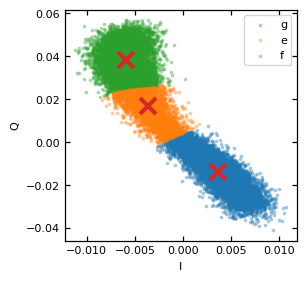

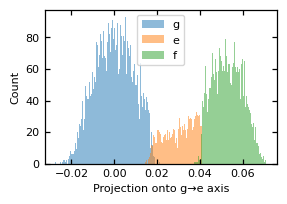

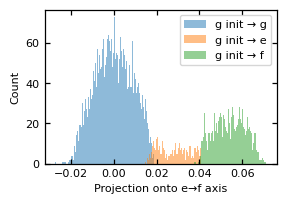

Initial state |g> → cluster fractions (g/e/f): [0.6183 0.1147 0.267 ]


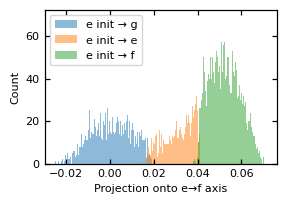

Initial state |e> → cluster fractions (g/e/f): [0.2151 0.2439 0.541 ]


In [60]:
from sklearn.mixture import GaussianMixture

X = np.vstack([to_IQ(signal_g), to_IQ(signal_e)])

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    n_init=20,
    random_state=0
).fit(X)

labels = gmm.predict(X)
centers = gmm.means_

r2 = np.sum(centers**2, axis=1)
idx_sorted = np.argsort(r2)

center_g = centers[idx_sorted[0]]
center_e = centers[idx_sorted[1]]
center_f = centers[idx_sorted[2]]

label_map = np.zeros_like(labels)
for i, idx in enumerate(idx_sorted):
    label_map[labels == idx] = i   # 0=g, 1=e, 2=f

colors = ["tab:blue", "tab:orange", "tab:green"]  # g/e/f


plt.figure(figsize=(3,3))
for i, c in enumerate(colors):
    plt.scatter(
        X[label_map==i, 0], X[label_map==i, 1],
        s=3, color=c, alpha=0.3, label=f"{['g','e','f'][i]}"
    )
for i, c in enumerate(colors):
    plt.plot(centers[idx_sorted[i],0], centers[idx_sorted[i],1],
             "x", color="tab:red", markersize=12, markeredgewidth=3)

plt.xlabel("I")
plt.ylabel("Q")
# plt.title("GMM(3) clustering (g/e/f peaks)")
plt.legend()
plt.show()

vec = center_e - center_g
unit_vec = vec / np.linalg.norm(vec)
proj = (X - center_g) @ unit_vec

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj[label_map==i], bins=200, alpha=0.5, color=c, label=f"{['g','e','f'][i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
# plt.title("1D Projection along g→e line")
plt.legend()
plt.show()

X_g = to_IQ(signal_g)  
X_e = to_IQ(signal_e)  
# --- g→f の射影方向 ---
vec_ef = center_f - center_e
unit_vec_ef = vec_ef / np.linalg.norm(vec_ef)

# --- 射影 ---
proj_g_only_ef = (X_g - center_g) @ unit_vec_ef
proj_e_only_ef = (X_e - center_g) @ unit_vec_ef

colors = ["tab:blue", "tab:orange", "tab:green"]  # g/e/f
labels_name = ["g", "e", "f"]

N_g = len(X_g)
N_e = len(X_e)

label_map_g = label_map[:N_g]
label_map_e = label_map[N_g:]

# --- g 初期化のヒストグラム ---
plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj_g_only_ef[label_map_g==i], bins=200, alpha=0.5, color=c, label=f"g init → {labels_name[i]}")

plt.xlabel("Projection onto e→f axis")
plt.ylabel("Count")
plt.legend()
plt.show()

counts_g = np.array([np.sum(label_map_g == i) for i in range(3)])
fractions_g = counts_g / counts_g.sum()
print("Initial state |g> → cluster fractions (g/e/f):", fractions_g)

# --- e 初期化のヒストグラム ---
plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj_e_only_ef[label_map_e==i], bins=200, alpha=0.5, color=c, label=f"e init → {labels_name[i]}")

plt.xlabel("Projection onto e→f axis")
plt.ylabel("Count")
plt.legend()
plt.show()

counts_e = np.array([np.sum(label_map_e == i) for i in range(3)])
fractions_e = counts_e / counts_e.sum()
print("Initial state |e> → cluster fractions (g/e/f):", fractions_e)


In [20]:
import numpy as np

# proj_g をリストから numpy 配列に変換
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()
mean_g = dd["pulse_g"]["values"].ravel()
mean_e = dd["pulse_e"]["values"].ravel()
ein_vec = (mean_e - mean_g) / np.sum((mean_e - mean_g)**2)


proj_g = [np.dot(el - mean_g, ein_vec) for el in signal_g]
proj_g = np.array(proj_g)

# 複素数になっている要素
complex_idx = np.where(np.iscomplex(proj_g))[0]
if len(complex_idx) > 0:
    print("Complex entries in proj_g at indices:", complex_idx)
    print("Values:", proj_g[complex_idx])

# NaN / Inf の要素
nan_idx = np.where(np.isnan(proj_g))[0]
if len(nan_idx) > 0:
    print("NaN entries in proj_g at indices:", nan_idx)
    print("Values:", proj_g[nan_idx])

inf_idx = np.where(np.isinf(proj_g))[0]
if len(inf_idx) > 0:
    print("Inf entries in proj_g at indices:", inf_idx)
    print("Values:", proj_g[inf_idx])

# もし複素数がある場合は、実部・虚部も出力
if len(complex_idx) > 0:
    print("Real part:", np.real(proj_g[complex_idx]))
    print("Imag part:", np.imag(proj_g[complex_idx]))


Complex entries in proj_g at indices: [   0    1    2 ... 9997 9998 9999]
Values: [0.00200261+0.01132236j 0.0019256 -0.0021771j  0.00219964-0.00247113j ...
 0.00303353-0.00470586j 0.0009477 +0.00862898j 0.00248598-0.00342302j]
Real part: [0.00200261 0.0019256  0.00219964 ... 0.00303353 0.0009477  0.00248598]
Imag part: [ 0.01132236 -0.0021771  -0.00247113 ... -0.00470586  0.00862898
 -0.00342302]


thermal population: 0.6956


IndexError: index -271 is out of bounds for axis 0 with size 201

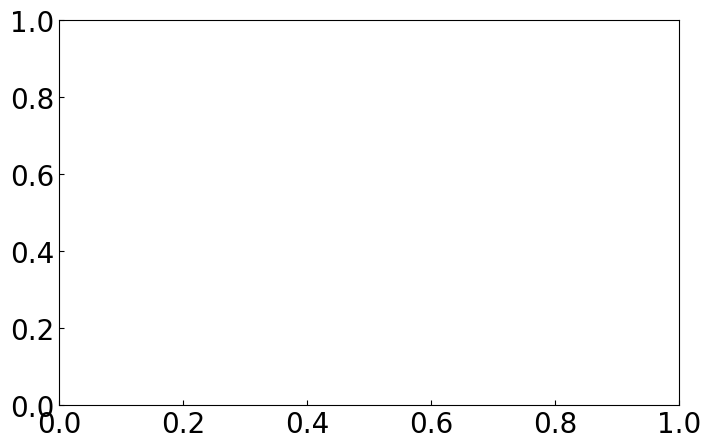

In [44]:
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()
mean_g = dd["pulse_g"]["values"].ravel()
mean_e = dd["pulse_e"]["values"].ravel()

# 正規化ベクトル
ein_vec = (mean_e - mean_g) / np.sum((mean_e - mean_g)**2)

# 投影計算（複素数のまま）
proj_g = [np.dot(el - mean_g, ein_vec) for el in signal_g]
proj_e = [np.dot(el - mean_g, ein_vec) for el in signal_e]

# 描画に問題を起こす値を除去（NaN / Inf / ±0 など）
proj_g_clean = [p for p in proj_g if np.isfinite(p)]
proj_e_clean = [p for p in proj_e if np.isfinite(p)]

# threshold 計算
thr = (np.mean(proj_g_clean) + np.mean(proj_e_clean)) / 2

# thermal population
thermal_population = np.mean([p > thr for p in proj_g_clean])
print(f"thermal population: {thermal_population:.4f}")

# histogram 用の bin 範囲を安全に設定
bin_min = min(np.min(proj_g_clean), np.min(proj_e_clean))
bin_max = max(np.max(proj_g_clean), np.max(proj_e_clean))
margin = 1e-15  # 極端に狭いレンジの場合の安全マージン
bin_min -= margin
bin_max += margin

# プロット
plt.figure(figsize=(8,5))
plt.hist(proj_g_clean, bins=200, range=(bin_min, bin_max), alpha=0.5, label="g")
plt.hist(proj_e_clean, bins=200, range=(bin_min, bin_max), alpha=0.5, label="e")
plt.axvline(thr, color="k", linestyle="--", label="threshold")

plt.xlabel("$S_{11}$ (arb. u.)")
plt.ylabel("Count")
plt.legend()

plt.show()

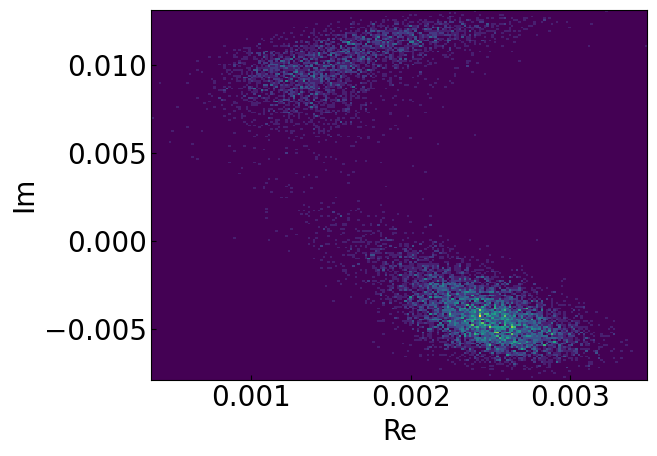

In [45]:
plt.hist2d(np.real(proj_g_clean), np.imag(proj_g_clean), bins=200)
plt.xlabel("Re")
plt.ylabel("Im")
plt.show()


thermal population: 0.6956


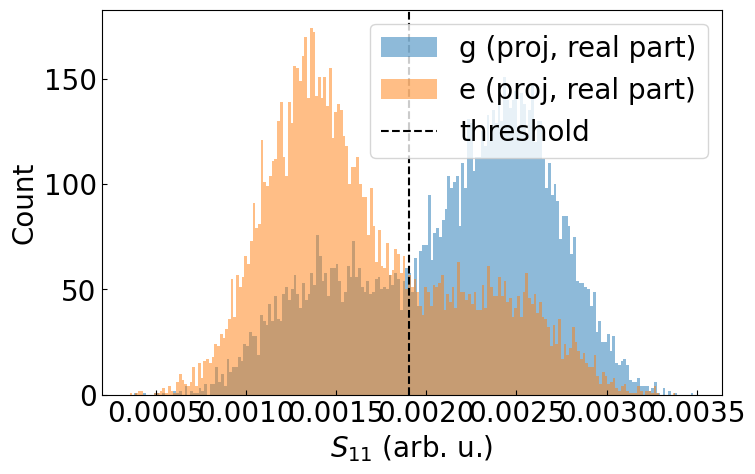

In [19]:
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()
mean_g = dd["pulse_g"]["values"].ravel()
mean_e = dd["pulse_e"]["values"].ravel()

ein_vec = (mean_e - mean_g) / np.sum((mean_e - mean_g)**2)

# proj_g, proj_e は複素数のままで thermal population を計算
proj_g = [np.dot(el - mean_g, ein_vec) for el in signal_g]
proj_e = [np.dot(el - mean_g, ein_vec) for el in signal_e]

thr = (np.mean(proj_g) + np.mean(proj_e)) / 2

# thermal population は proj_g > thr の割合
thermal_population = np.mean([p > thr for p in proj_g])  # real 部で比較
print(f"thermal population: {thermal_population:.4f}")

# ヒストグラムは実部または絶対値で描画
plt.figure(figsize=(8,5))
plt.hist([p.real for p in proj_g], bins=200, alpha=0.5, label="g (proj, real part)")
plt.hist([p.real for p in proj_e], bins=200, alpha=0.5, label="e (proj, real part)")

plt.axvline(thr.real, color="k", linestyle="--", label="threshold")

plt.xlabel("$S_{11}$ (arb. u.)")
plt.ylabel("Count")
plt.legend()
plt.show()


readout fidelity

readout fidelity for g: 0.9897132851827534
readout fidelity for e: 0.9841561165630385


Text(0, 0.5, '$S_{11}$ (arb. u.)')

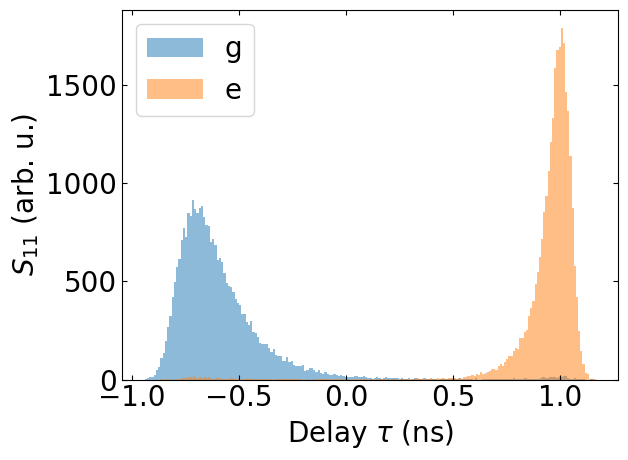

In [46]:
data = "/2025-08-13/2025-08-13T105252_394e37cc-i3_readout_fidelity"  #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()

plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.hist(signal_g, bins=200, alpha=0.5, log=0, label= "g")
plt.hist(signal_e, bins=200, alpha=0.5, label= "e")
print(f"readout fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"readout fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e)}")

plt.title("")
plt.legend()
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")

QND fidelity for g: 0.9926005401605683
QND fidelity for e: 0.9754072681704261


Text(0, 0.5, '$S_{11}$ (arb. u.)')

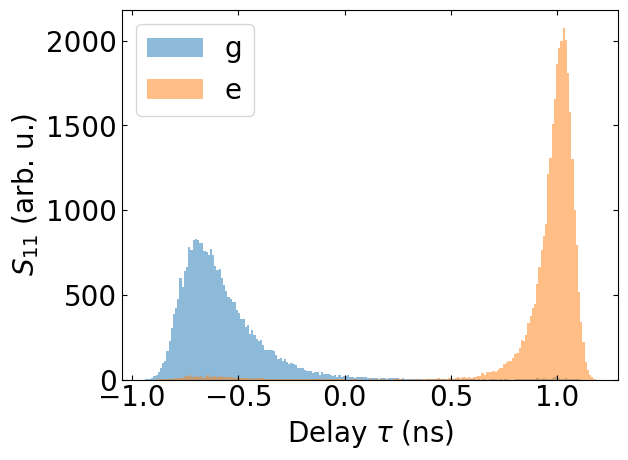

In [52]:


data = "/2025-08-13/2025-08-13T135900_39ef73d6-i4_QND_fidelity" #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()

plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.hist(signal_g, bins=200, alpha=0.5, log=0, label= "g")
plt.hist(signal_e, bins=200, alpha=0.5, label= "e")
print(f"QND fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"QND fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e)}")

plt.title("")
plt.legend()
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")